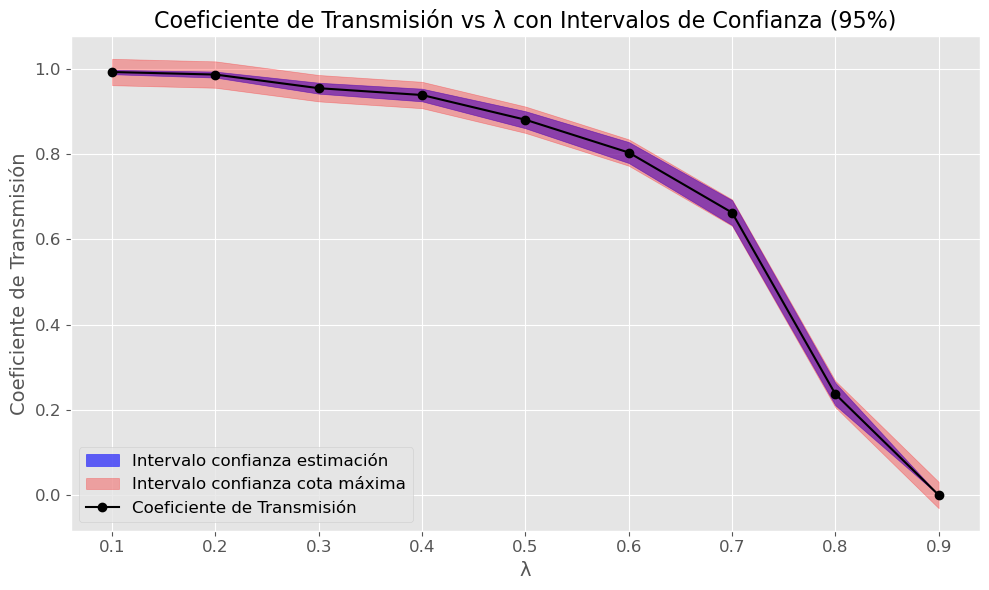

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Utilizar el estilo ggplot de Matplotlib
plt.style.use('ggplot')

# Definir la función para leer el archivo y obtener el coeficiente de transmisión
def read_transmission(file_name):
    Transmission = []
    with open(file_name, 'r') as file:
        next(file)  # Saltar la primera línea si tiene encabezados
        for line in file:
            data = line.strip().split(',')
            Transmission.append(float(data[2].strip()))
    return Transmission[-1]  # Retornar el último valor de coeficiente de transmisión

# Función para calcular el intervalo de confianza usando la desviación estándar estimada
def confidence_interval_std(T, N_exp):
    sigma_hat = np.sqrt(T * (1 - T))
    z_alpha_2 = 1.96  # Valor crítico para un intervalo de confianza del 95%
    interval = z_alpha_2 * sigma_hat / np.sqrt(N_exp)
    return interval

# Función para calcular el intervalo de confianza usando una cota superior de sigma
def confidence_interval_max(T, N_exp):
    sigma_max = 0.5  # Máximo valor posible de sigma para una distribución de Bernoulli
    z_alpha_2 = 1.96  # Valor crítico para un intervalo de confianza del 95%
    interval = z_alpha_2 * sigma_max / np.sqrt(N_exp)
    return interval

# Lista para almacenar los valores de lambda y los coeficientes de transmisión
lambda_values = []
transmission_values = []

# Leer los archivos .txt para diferentes valores de lambda
lambda_range = np.arange(0.1, 1.0, 0.1)
for lambda_val in lambda_range:
    file_name = f'lambda={lambda_val:.1f}.txt'
    if os.path.exists(file_name):
        lambda_values.append(lambda_val)
        T = read_transmission(file_name)
        transmission_values.append(T)

# Calcular los intervalos de confianza para N_exp = 1000
N_exp = 1000
intervals_std = []
intervals_max = []

for T in transmission_values:
    interval_std = confidence_interval_std(T, N_exp)
    interval_max = confidence_interval_max(T, N_exp)
    intervals_std.append(interval_std)
    intervals_max.append(interval_max)

# Graficar el coeficiente de transmisión respecto a lambda con intervalos de confianza
plt.figure(figsize=(10, 6))

# Graficar los intervalos de confianza con fill_between
plt.fill_between(lambda_values, np.array(transmission_values) - np.array(intervals_std),
                 np.array(transmission_values) + np.array(intervals_std), color='blue', alpha=0.6, label='Intervalo confianza estimación')
plt.fill_between(lambda_values, np.array(transmission_values) - np.array(intervals_max),
                 np.array(transmission_values) + np.array(intervals_max), color='red', alpha=0.3, label='Intervalo confianza cota máxima')

plt.plot(lambda_values, transmission_values, 'ko-', label='Coeficiente de Transmisión', markersize=6)

plt.title('Coeficiente de Transmisión vs λ con Intervalos de Confianza (95%)', fontsize=16)
plt.xlabel('λ', fontsize=14)
plt.ylabel('Coeficiente de Transmisión', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.legend(fontsize=12, loc='lower left')
plt.tight_layout()
plt.show()
